In [1]:
import numpy as np
import matplotlib.pyplot as plt
# import seaborn as sns
from tda_methods import LSTMAutoencoder, ZForecaster, GeometryConverter, PersistencePlotter, TakensEmbedding, WassersteinDistance, \
      plot_3d_points, numpy_to_torch, window_2d_sequence_to_3d, write_results_to_file, plot_all_features_in_2d_array, plot_latent_evolution_grid
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn


In [ ]:
"Torus/Sphere data"

rng     = np.random.default_rng()
start_point, end_point, n_points = 0, 2*np.pi, 1000
u_angle = rng.uniform(start_point, end_point, n_points)
v_angle = rng.uniform(start_point, end_point, n_points)

# u, v = np.meshgrid(u, v)

R_major   = 1
r_tube    = R_major/4
converter = GeometryConverter(R_major, r_tube)
x, y, z   = converter.convert_angles_to_torus_xyz(u_angle, v_angle)
# # x, y, z   = converter.convert_angles_to_sphere_xyz(u_angle, v_angle)
noise = rng.normal(0, 0.04, n_points)
x += noise  # Add some noise to v
y += noise  # Add some noise to u
z += noise  # Add some noise to both
geo_coordinates = np.column_stack((x, y, z))  # shape (N, 3)

# x1,y1,z1,x2,y2,z2 = converter.convert_angles_to_2torus_xyz(u_angle, v_angle, d_shift=R_major)
# geo_coordinates   = np.vstack([np.column_stack((x1,y1,z1)), np.column_stack((x2,y2,z2))])
plot_3d_points((geo_coordinates[:, 0], geo_coordinates[:, 1], geo_coordinates[:, 2]))


In [ ]:
"persistence"

persistence    = PersistencePlotter(max_dim=1)
diagrams_list  = persistence.compute_persistence_diagrams(geo_coordinates)
diagrams_clean = persistence.remove_inf(diagrams_list)
entropy_array  = persistence.compute_entropy(diagrams_clean)
persistence_images_list = persistence.compute_persistence_image(diagrams_clean)
betti_curves_array      = persistence.compute_betti_curves(diagrams_clean)

print("Persistence array:", entropy_array)
print("Betti curves shape: (batch, homology_dim, filtration_steps) =", betti_curves_array.shape)

persistence.plot_persistence_diagrams(diagrams_list)
persistence.plot_entropy(entropy_array)
persistence.plot_persistence_image(persistence_images_list[1])  # H1
persistence.plot_betti_curves(betti_curves_array)


In [ ]:
"timedelay embeddings"

x  = np.linspace(0, 14*np.pi, 1000)
y1 = (0.5+0.5*x) * np.sin(2*x + 1) + 0.04 * rng.normal(size=x.shape)
y2 = 1.5*np.sin(2 * x) #+ 0.05 * (x-2)**1.2 #+ 0.02 * rng.normal(size=x.shape)
plt.figure()
plt.plot(x, y1, label='y1')
plt.plot(x, y2, label='y2')
plt.legend()
plt.show()

min_len = min(len(y1), len(y2))
y1, y2  = y1[:min_len], y2[:min_len]

time_delay, lag_dim = 20, 4
y1_delay_embeddings = make_timedelay_embeddings(y1, time_delay, lag_dim)
y1_now, y1_delayed  = y1_delay_embeddings[:, 0], y1_delay_embeddings[:, 1]

# time_delay2, lag_dim2 = 20, 4
y2_delay_embeddings = make_timedelay_embeddings(y2, time_delay, lag_dim)
y2_now, y2_delayed  = y2_delay_embeddings[:, 0], y2_delay_embeddings[:, 1]
plt.figure()
# plt.scatter(y1_now, y1_delayed, s=4)
plt.scatter(y2_now, y2_delayed, s=4)
plt.show()

# persistence stuff
persistence  = PersistencePlotter(max_dim=1)
n            = min(len(y1_delay_embeddings), len(y2_delay_embeddings))
y_all        = np.hstack((y1_delay_embeddings[:n], y2_delay_embeddings[:n]))
# y_data       = np.column_stack((y1_now, y1_delayed))
diagrams_list = persistence.compute_persistence_diagrams(y_all)
persistence.plot_persistence_diagrams(diagrams_list, title="y_all")


X shape (15000, 3)
X_windows shape: (1139, 200, 3)
X_train/test shape: (911, 200, 3) (228, 200, 3)


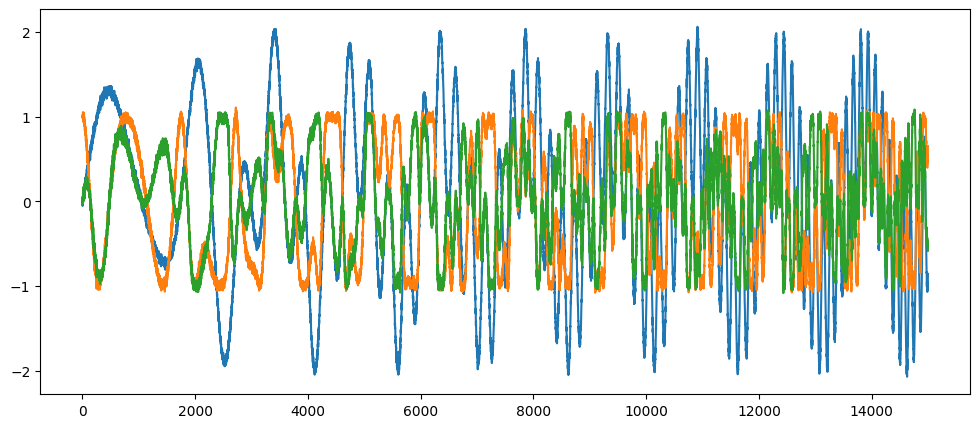

In [2]:
"⚽️ Setting up data"
rng     = np.random.default_rng()

num_timesteps = 15_000
timesteps     = np.linspace(0, 20*np.pi, num_timesteps)
# X1 = np.sin(timesteps) * ((0.5+0.5*timesteps) * np.sin(2*timesteps + 1)) + 0.03 * rng.normal(size=timesteps.shape)
# X1 = (2.0 * np.sin(0.2 * timesteps)) + 0.5 * np.sin(2*timesteps) + 0.03 * rng.normal(size=timesteps.shape)
# X2 = np.cos(3*timesteps + 1) + 0.5 * np.sin(2*timesteps) + 0.03 * rng.normal(size=timesteps.shape)
# X3 = -(4.0 * np.sin(0.8 * timesteps)) + 0.8 * np.sin(4*timesteps) + 0.03 * rng.normal(size=timesteps.shape)
# X  = np.column_stack((X1, X2, X3))
X1 = np.sin(timesteps) + np.sin(0.1* timesteps**2) + 0.03 * rng.normal(size=timesteps.shape)
X2 = np.cos(1.7 * timesteps + X1) + 0.03 * rng.normal(size=timesteps.shape)
X3 = np.sin(X2 * X1) + 0.03 * rng.normal(size=timesteps.shape)
X = np.column_stack((X1, X2, X3))

window_size     = 200
stride          = window_size//15
X_windows       = window_2d_sequence_to_3d(X, window_size, stride)
X_train_3d, X_test_3d = train_test_split(X_windows, test_size=0.2, random_state=42, shuffle=False)

# scaling works for 2d, so reshape to 2d, scale, and reshape back
scaler         = StandardScaler()
X_train_2d     = X_train_3d.reshape(-1, X_train_3d.shape[-1])
X_test_2d      = X_test_3d.reshape(-1, X_test_3d.shape[-1])
X_train = scaler.fit_transform(X_train_2d).reshape(X_train_3d.shape)
X_test  = scaler.transform(X_test_2d).reshape(X_test_3d.shape)

# takens_object   = TakensEmbedding(delay=8, embedding_dim=3)
# X_train_takens  = takens_object.make_timedelay_embeddings_grid(X_train)
# X_test_takens   = takens_object.make_timedelay_embeddings_grid(X_test)

print("X shape", X.shape)
print("X_windows shape:", X_windows.shape)
print("X_train/test shape:", X_train.shape, X_test.shape)

plt.figure(figsize=(12, 5))
plt.plot(X1, label='Original Data')
plt.plot(X2, label='Original Data')
plt.plot(X3, label='Original Data')


Epoch 20/100, Loss: 0.0097
Early stopping at epoch 33, loss = 0.0092


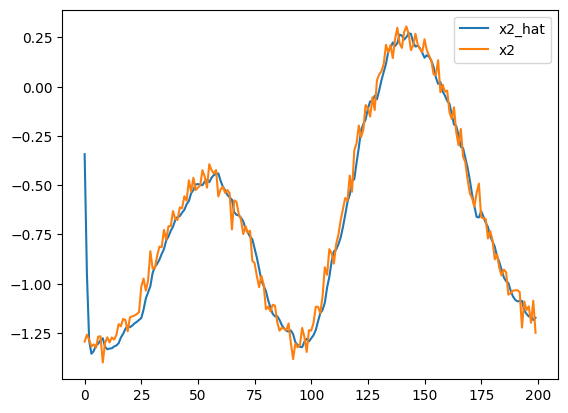

In [ ]:
"⚽️ train + eval LSTM encoder"

X_train, X_test    = numpy_to_torch(X_train), numpy_to_torch(X_test)
input_dim          = X_train.shape[-1]
latent_dim         = 8
encoder_hidden_dim = 56
decoder_hidden_dim = 56
lstm_ae            = LSTMAutoencoder(input_dim, latent_dim, encoder_hidden_dim=encoder_hidden_dim,
                             decoder_hidden_dim=decoder_hidden_dim, epochs=100, learning_rate=0.001)
losses             = lstm_ae.train_model(X_train, patience=12)
device             = lstm_ae.device

# inference:
lstm_ae.eval()
with torch.no_grad():
    x_train_hat, z_train = lstm_ae(X_train.to(device))
    x_test_hat, z_test   = lstm_ae(X_test.to(device))

#scale z while staying on torch
mean    = z_train.mean(dim=0)
std     = z_train.std(dim=0) + 1e-8
z_train = (z_train - mean) / std
z_test  = (z_test - mean) / std

# visual test that encoder works on x_test
window_number, feature_number = 2, 1
plt.plot(x_test_hat[window_number, :, feature_number].cpu(), label=f'x{window_number}_hat')
plt.plot(X_test[window_number, :, feature_number].cpu(), label=f'x{window_number}')
plt.legend()
plt.show()


z_train=torch.Size([911, 8]), z_train_win= torch.Size([63, 100, 8])
z_test=torch.Size([228, 8]), z_test_win= torch.Size([10, 100, 8])


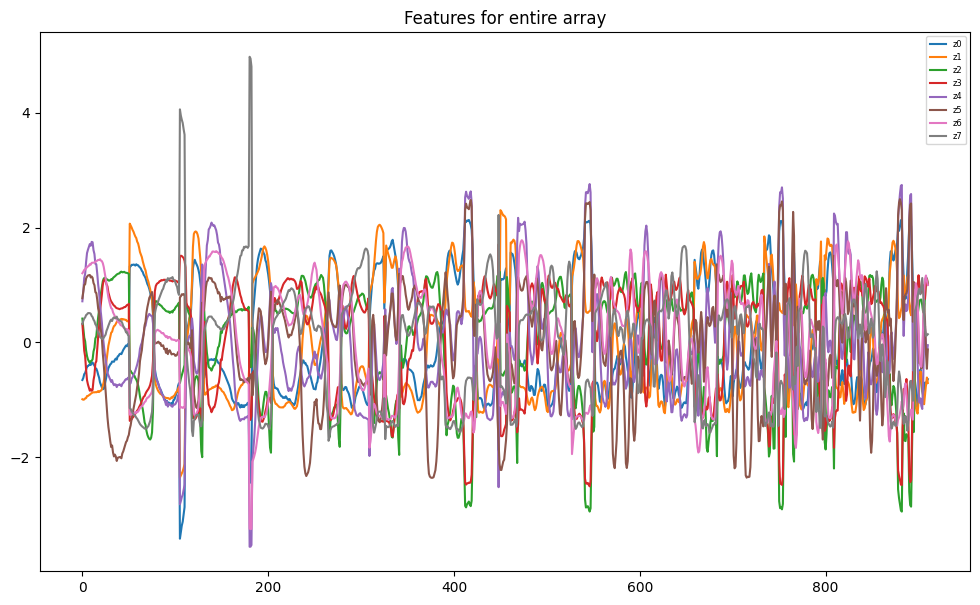

/home/fouadabiad/projects/timeseries_geo_ml/geo/topological_analysis/tda_methods.py:768: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(right=0.88) # right-side colorbar


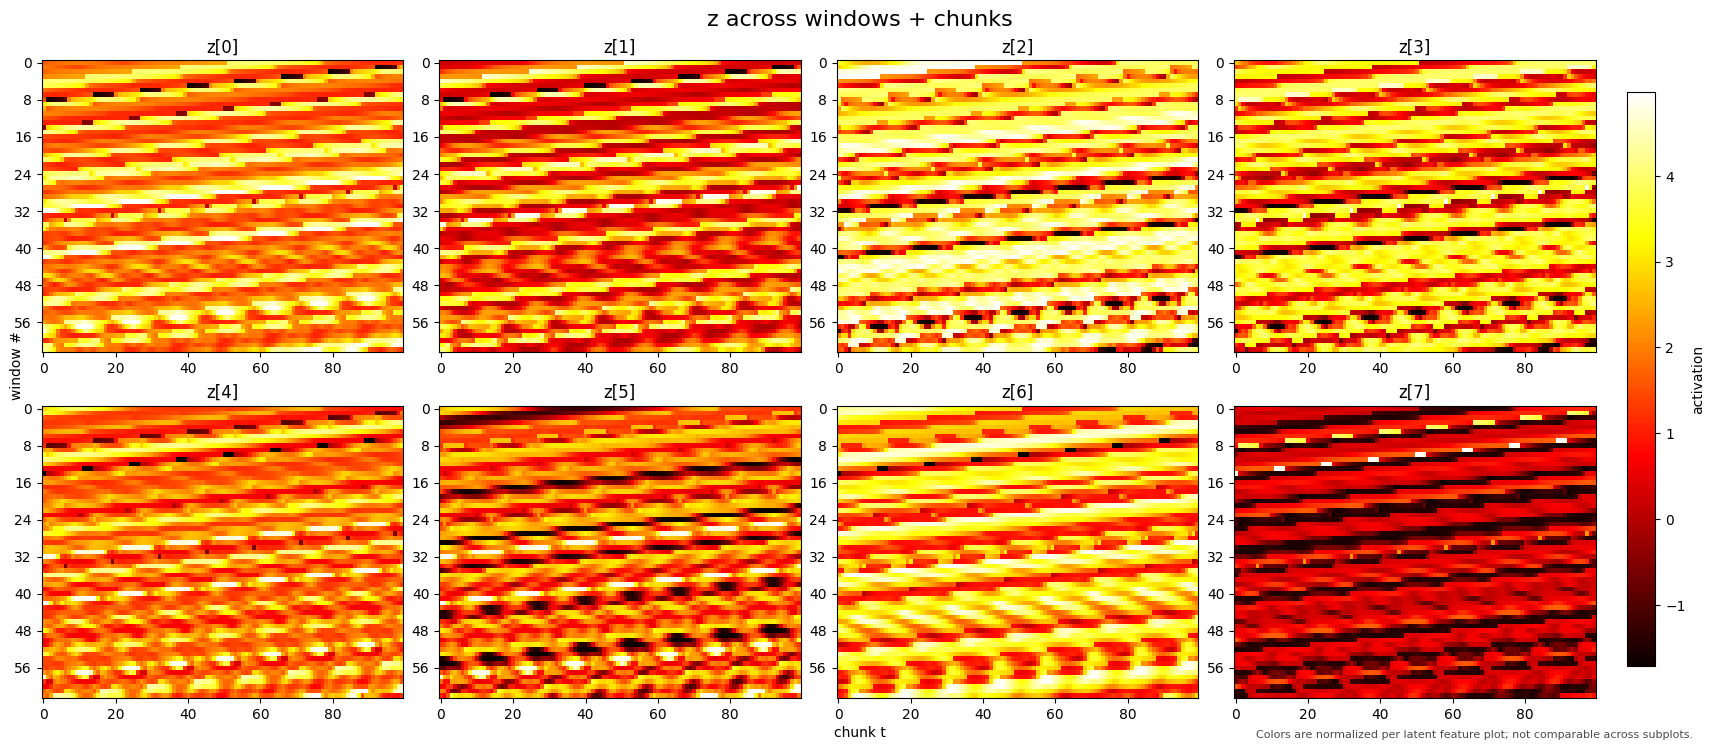

In [ ]:
"⚽️ windowing latents z"

z_window_size   = 100
z_window_stride = 8
z_train_windows = window_2d_sequence_to_3d(z_train, z_window_size, stride)
z_test_windows  = window_2d_sequence_to_3d(z_test,  z_window_size, stride)

print(f"z_train={z_train.shape}, z_train_win= {z_train_windows.shape}")
print(f"z_test={z_test.shape}, z_test_win= {z_test_windows.shape}")
plot_all_features_in_2d_array(z_train, window_number=1)
plot_latent_evolution_grid(z_train_windows, max_latent_dims=8, n_plots_per_row=4)


epoch 10 loss 1.0620
epoch 20 loss 0.8651
epoch 30 loss 0.6669
epoch 40 loss 0.6432
epoch 50 loss 0.6007
Test MSE: 0.6660
Z_hat_train: torch.Size([62, 100, 8]), Z_hat_test: torch.Size([9, 100, 8])


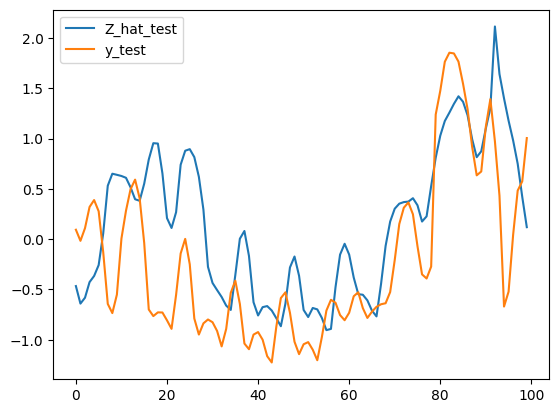

In [ ]:
"⚽️ forecasting z"
"TODO: fix current z forecasting model (its not good, super simple)"

H = 1 # forecasting horizon (in windows, not rows)
x_train = z_train_windows[:-H]
y_train = z_train_windows[H:] #to predict
x_test  = z_test_windows[:-H]
y_test  = z_test_windows[H:]  #to predict
x_train = torch.as_tensor(x_train, dtype=torch.float32)
y_train = torch.as_tensor(y_train, dtype=torch.float32)
x_test  = torch.as_tensor(x_test, dtype=torch.float32)
y_test  = torch.as_tensor(y_test, dtype=torch.float32)

class ZForecaster(nn.Module):
    """Very simple 3D LSTM encoder-decoder for forecasting latent z"""
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.encoder = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.decoder = nn.LSTM(input_dim, hidden_dim, batch_first=True)  # FIX
        self.fc      = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        _, (h, c) = self.encoder(x)
        out, _ = self.decoder(x, (h, c))  # teacher forcing style
        return self.fc(out) + x #residual

def train_forecaster(model, x_train, y_train, x_test, y_test, epochs=50, lr=1e-3, batch_size=32):
    device  = next(model.parameters()).device
    opt     = torch.optim.AdamW(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    loader  = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(x_train, y_train),
                                          batch_size=batch_size, shuffle=True)
    for e in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
        if (e+1) % 10 == 0:
            print(f"epoch {e+1} loss {loss.item():.4f}")

    model.eval()
    with torch.no_grad():
        y_hat    = model(x_test.to(device)) # forecasted latent z
        loss_dyn = loss_fn(y_hat, y_test.to(device)).item()
    return loss_dyn

input_dim  = z_train_windows.shape[-1]
hidden_dim = 64
model      = ZForecaster(input_dim, hidden_dim, input_dim).to(device)

z_mse = train_forecaster(model, x_train, y_train, x_test, y_test)
print(f"Test MSE: {z_mse:.4f}")

model.eval()
with torch.no_grad():
    Z_hat_train = model(x_train.to(device)).cpu()
    Z_hat_test  = model(x_test.to(device)).cpu()

print(f"Z_hat_train: {Z_hat_train.shape}, Z_hat_test: {Z_hat_test.shape}")

plt.plot(Z_hat_test[0, :, 1], label='Z_hat_test')
plt.plot(y_test[0, :, 1].cpu(), label='y_test')
plt.legend()
plt.show()


In [ ]:
"⚠️ moved takens stuff temporarily here"

takens_obj     = TakensEmbedding(delay=10, embedding_dim=3)
z_train_takens = takens_obj.make_timedelay_embeddings_grid(z_train_windows)
z_test_takens  = takens_obj.make_timedelay_embeddings_grid(z_test_windows)
# plotter        = PersistencePlotter(max_dim=2, pixel_size=0.2)
# dgms           = plotter.remove_inf(plotter.compute_persistence_diagrams(z_train_takens[0]))

print(f"z_win_takens= {z_train_takens.shape}")

plotter.plot_persistence_diagrams(dgms)

# A(t) = mean_k corr(z[:,k], z[:,k+τ]) # acf decides the best window size

window = 2
plot_3d_points((z_train_takens[window][:, 0], z_train_takens[window][:, 1], z_train_takens[window][:, 2]), figsize=(6, 9))
plot_3d_points((z_train_windows[window][:, 0], z_train_windows[window][:, 1], z_train_windows[window][:, 2]), figsize=(6, 9))

In [ ]:
"⚽️ persistence + d_wasserstein + plotting"

plotter = PersistencePlotter(max_dim=2, pixel_size=0.2)
d_wasser_obj = WassersteinDistance

# ALIGNMENT FIX
z_true_test = z_test_windows[1:]   # (9, 100, 8)
z_hat_test  = Z_hat_test           # (9, 100, 8)

z_true_train = z_train_windows[1:]
z_hat_train  = Z_hat_train

print("train aligned:", z_true_train.shape, z_hat_train.shape)
print("test aligned :", z_true_test.shape, z_hat_test.shape)

# PERSISTENCE FEATURES
true_betti_train = plotter.compute_persistence_features(z_true_train, mode="betti")
hat_betti_train  = plotter.compute_persistence_features(z_hat_train, mode="betti")

true_betti_test = plotter.compute_persistence_features(z_true_test, mode="betti")
hat_betti_test  = plotter.compute_persistence_features(z_hat_test, mode="betti")

# TOPOLOGY LOSS (WASSERSTEIN)
betti_dist_train = d_wasser_obj.compute_wasserstein_distance(true_betti_train, hat_betti_train, delay=1)
betti_dist_test  = d_wasser_obj.compute_wasserstein_distance(true_betti_test, hat_betti_test, delay=1)

# OUTPUT SHAPES + SUMMARY
print("train betti dist shape:", betti_dist_train.shape)
print("test betti dist shape :", betti_dist_test.shape)

print("train mean topo error:", betti_dist_train.mean().item())
print("test mean topo error :", betti_dist_test.mean().item())

# ==============
# X_hat, non-Takens

# plotter        = PersistencePlotter(max_dim=2, pixel_size=0.2)
# dgms           = plotter.remove_inf(plotter.compute_persistence_diagrams(Z_hat_train[0]))
# z_betti_train    = plotter.compute_persistence_features(Z_hat_train, mode="betti")
# z_image_train    = plotter.compute_persistence_features(Z_hat_train, mode="image")
# z_diagram_train  = plotter.compute_persistence_features(Z_hat_train, mode="diagram")
# z_landscape_train= plotter.compute_persistence_features(Z_hat_train, mode="landscape")

# z_betti_test    = plotter.compute_persistence_features(Z_hat_test, mode="betti")
# z_image_test    = plotter.compute_persistence_features(Z_hat_test, mode="image")
# z_diagram_test  = plotter.compute_persistence_features(Z_hat_test, mode="diagram")
# z_landscape_test= plotter.compute_persistence_features(Z_hat_test, mode="landscape")

# d_wasser_obj         = WassersteinDistance
# betti_dist_train     = d_wasser_obj.compute_wasserstein_distance(z_betti_train, delay=1)
# image_dist_train     = d_wasser_obj.compute_wasserstein_distance(z_image_train, delay=1)
# diagram_dist_train   = d_wasser_obj.compute_wasserstein_distance(z_diagram_train, delay=1)
# landscape_dist_train = d_wasser_obj.compute_wasserstein_distance(z_landscape_train, delay=1)

# betti_dist_test     = d_wasser_obj.compute_wasserstein_distance(z_betti_test, delay=1)
# image_dist_test     = d_wasser_obj.compute_wasserstein_distance(z_image_test, delay=1)
# diagram_dist_test   = d_wasser_obj.compute_wasserstein_distance(z_diagram_test, delay=1)
# landscape_dist_test = d_wasser_obj.compute_wasserstein_distance(z_landscape_test, delay=1)

# print(np.array2string(betti_dist_train, formatter={'float_kind': lambda x: f"{x:.2e}"}))
# print(np.array2string(image_dist_train, formatter={'float_kind': lambda x: f"{x:.2e}"}))
# print(np.array2string(diagram_dist_train, formatter={'float_kind': lambda x: f"{x:.2e}"}))
# print(np.array2string(landscape_dist_train, formatter={'float_kind': lambda x: f"{x:.2e}"}))

# d_wasser_obj.plot_all_wasserstein_distances(betti_dist_train, image_dist_train, diagram_dist_train, landscape_dist_train)

# ===============
# Takens

# z_betti_train    = plotter.compute_persistence_features(z_train_takens, mode="betti")
# z_image_train    = plotter.compute_persistence_features(z_train_takens, mode="image")
# z_diagram_train  = plotter.compute_persistence_features(z_train_takens, mode="diagram")
# z_landscape_train= plotter.compute_persistence_features(z_train_takens, mode="landscape")

# z_betti_test    = plotter.compute_persistence_features(z_test_takens, mode="betti")
# z_image_test    = plotter.compute_persistence_features(z_test_takens, mode="image")
# z_diagram_test  = plotter.compute_persistence_features(z_test_takens, mode="diagram")
# z_landscape_test= plotter.compute_persistence_features(z_test_takens, mode="landscape")

# print("betti features shape:", z_betti_train.shape)
# plotter.plot_persistence_grid(z_train_windows)
# plotter.plot_persistence_image_grid(z_train_windows)
# plotter.plot_betti_grid(z_train_windows)
# plotter.plot_landscape_grid(z_train_windows, num_steps=128, K_layers=3)

# d_wasser_obj         = WassersteinDistance
# betti_dist_train     = d_wasser_obj.compute_wasserstein_distance(z_betti_train, delay=1)
# image_dist_train     = d_wasser_obj.compute_wasserstein_distance(z_image_train, delay=1)
# diagram_dist_train   = d_wasser_obj.compute_wasserstein_distance(z_diagram_train, delay=1)
# landscape_dist_train = d_wasser_obj.compute_wasserstein_distance(z_landscape_train, delay=1)

# betti_dist_test     = d_wasser_obj.compute_wasserstein_distance(z_betti_test, delay=1)
# image_dist_test     = d_wasser_obj.compute_wasserstein_distance(z_image_test, delay=1)
# diagram_dist_test   = d_wasser_obj.compute_wasserstein_distance(z_diagram_test, delay=1)
# landscape_dist_test = d_wasser_obj.compute_wasserstein_distance(z_landscape_test, delay=1)

# print(np.array2string(betti_dist_train, formatter={'float_kind': lambda x: f"{x:.2e}"}))
# print(np.array2string(image_dist_train, formatter={'float_kind': lambda x: f"{x:.2e}"}))
# print(np.array2string(diagram_dist_train, formatter={'float_kind': lambda x: f"{x:.2e}"}))
# print(np.array2string(landscape_dist_train, formatter={'float_kind': lambda x: f"{x:.2e}"}))

# d_wasser_obj.plot_all_wasserstein_distances(betti_dist_train, image_dist_train, diagram_dist_train, landscape_dist_train)


train aligned: torch.Size([62, 100, 8]) torch.Size([62, 100, 8])
test aligned : torch.Size([9, 100, 8]) torch.Size([9, 100, 8])
train betti dist shape: (62,)
test betti dist shape : (9,)
train mean topo error: 4.51758064516129
test mean topo error : 3.7592592592592595


In [ ]:
"[BAD] waasserstein as exog. feature to z"
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torchmetrics.regression import R2Score

# CONFIG
USE_EXOGENOUS = 0
EXOG_FEATURES = ["betti"]
N_RUNS = 8
EPOCHS = 100
H      = 1 # prediction horizon

print(f"Using exogenous: {USE_EXOGENOUS} | Features: {EXOG_FEATURES} | Runs: {N_RUNS}")

exog_map = {
    "betti": {"train": betti_dist_train, "test": betti_dist_test},
    "image": {"train": image_dist_train, "test": image_dist_test},
    "diagram": {"train": diagram_dist_train, "test": diagram_dist_test},
    "landscape": {"train": landscape_dist_train, "test": landscape_dist_test}}

def build_sequences(z: torch.Tensor, H: int):
    """Create (x, y) sequences from z. y = next H steps of last latent dim, x = all latent dims except last, aligned with y."""
    idx = torch.arange(len(z)-H)
    x   = z[:-H]
    y   = torch.stack([z[i+1:i+H+1, -1, :] for i in idx])
    return x, y, idx

z_train_t = torch.tensor(z_train_takens, dtype=torch.float32, device=device)
z_test_t  = torch.tensor(z_test_takens,  dtype=torch.float32, device=device)

x_train, y_train, idx_train = build_sequences(z_train_t, H)
x_test, y_test, idx_test    = build_sequences(z_test_t, H)

n_rows = x_train.shape[1]
n_cols = x_train.shape[2]

print(f"b4 adding exogenous features, x_train shape: {x_train.shape}, x_test shape: {x_test.shape}")

def add_exogenous_features_to_X(X_train, X_test, idx_train, idx_test, exog_map, feature_names, device):
    """Adds exogenous features to input X_train/X_test tensors based on the provided exog_map and EXOG_FEATURES list
    if USE_EXOGENOUS = False, returns original X_train/X_test without modification
    if USE_EXOGENOUS = True, concats exogenous features to X_train/X_test along the feature dim"""
    exog_train_list, exog_test_list = [], []

    T = X_train.shape[1]

    for name in feature_names:
            train_full = torch.tensor(exog_map[name]["train"], dtype=torch.float32, device=device)
            test_full  = torch.tensor(exog_map[name]["test"], dtype=torch.float32, device=device)

            # Use the indices from build_sequences to align the data
            train = train_full[idx_train]
            test  = test_full[idx_test]

            # Reshape to (Batch, Time, 1) to match X_train/X_test
            train = train[:, None, None].expand(-1, X_train.shape[1], 1)
            test  = test[:, None, None].expand(-1, X_test.shape[1], 1)

            exog_train_list.append(train)
            exog_test_list.append(test)

    exog_train = torch.cat(exog_train_list, dim=-1)
    exog_test  = torch.cat(exog_test_list, dim=-1)

    mean = exog_train.mean()
    std = exog_train.std().clamp_min(1e-8)

    exog_train = (exog_train - mean) / std
    exog_test  = (exog_test - mean) / std

    return torch.cat([X_train, exog_train], dim=-1), torch.cat([X_test, exog_test], dim=-1)

if USE_EXOGENOUS:
    x_train, x_test = add_exogenous_features_to_X(x_train, x_test, idx_train, idx_test, exog_map, EXOG_FEATURES, device=device)

print(f"After adding exogenous features, x_train shape: {x_train.shape}, x_test shape: {x_test.shape}")

input_dim = x_train.shape[-1]

print("x_train:", x_train.shape)
print("exog train:", exog_map[EXOG_FEATURES[0]]["train"].shape)
print("Train:", x_train.shape, y_train.shape)
print("Test :", x_test.shape,  y_test.shape)


# def train_eval_forecaster(x_train: torch.Tensor, y_train: torch.Tensor, x_test: torch.Tensor, y_test: torch.Tensor, input_dim: int, n_cols: int, H: int, device: torch.device, n_runs: int = 8, epochs: int = 50, batch_size: int = 32, lr: float = 1e-3, hidden_dim: int = 64) -> tuple[float, float, float, float]:
#     """Train multiple runs of ZForecaster and return mean/std of MSE and R2."""
#     loss_fn = nn.MSELoss()
#     mse_list, r2_list = [], []

#     for run in range(n_runs):
#         torch.manual_seed(run)

#         model = ZForecaster(input_dim, hidden_dim, n_cols, H).to(device)
#         optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
#         loader = DataLoader(TensorDataset(x_train, y_train), batch_size=batch_size, shuffle=True)

#         for _ in range(epochs):
#             model.train()
#             for xb, yb in loader:
#                 optimizer.zero_grad()
#                 loss = loss_fn(model(xb), yb)
#                 loss.backward()
#                 optimizer.step()

#         model.eval()
#         with torch.no_grad():
#             y_pred = model(x_test)
#             mse = loss_fn(y_pred, y_test).item()

#         r2_metric = R2Score(multioutput='uniform_average').to(device)
#         r2 = r2_metric(
#             y_pred.reshape(-1, n_cols),
#             y_test.reshape(-1, n_cols)).item()

#         mse_list.append(mse)
#         r2_list.append(r2)
#         print(f"Run {run+1}/{n_runs} → MSE: {mse:.4f}, R²: {r2:.4f}")

#     mean_mse, std_mse = np.mean(mse_list), np.std(mse_list)
#     mean_r2, std_r2   = np.mean(r2_list), np.std(r2_list)
#     return mean_mse, std_mse, mean_r2, std_r2

mean_mse, std_mse, mean_r2, std_r2 = ZForecaster.train_eval_forecaster(
    x_train, y_train,
    x_test, y_test,
    input_dim=input_dim,
    n_cols=n_cols,
    H=H,
    device=device,
    n_runs=N_RUNS,
    epochs=EPOCHS)

results_line = (f"{EXOG_FEATURES=}, " if USE_EXOGENOUS else "NO EXOGENOUS FEATURES, ") + f"H={H}, MSE: {mean_mse:.4f}±{std_mse:.4f}, R²: {mean_r2:.4f}±{std_r2:.4f}\n"

print("\n" + results_line)
write_results_to_file(file="results.txt", line=results_line)


In [ ]:
"wrapper"

